# Telco Customer Churn Prediction
### An End-to-End Machine Learning Classification Project

**Dataset:** IBM Sample Data Sets — Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)
**Domain:** Telecommunications / Customer Retention Analytics


## Problem Statement
> *Given a customer's account, service, and billing attributes, can we accurately predict
> whether that customer is likely to churn, and, just as importantly, which factors are
> driving that risk?*

### Objectives
1. **Predictive objective** — Build and compare multiple supervised classification models
   that predict the binary target `Churn` (Yes/No) with strong recall and precision on the
   minority (churn) class, since missing a true churner is costlier to the business than a
   false alarm.
2. **Diagnostic objective** — Use exploratory data analysis and feature importance to
   surface *actionable* business insights (e.g., which contract types, payment methods, or
   tenure bands are associated with higher churn) that a retention team could act on
   directly.
3. **Evaluation objective** — Assess models not just on accuracy (which is misleading on an
   imbalanced dataset — ~73% Non-Churn vs ~27% Churn) but on precision, recall, F1-score,
   and ROC-AUC.

### Why This Matters
This is a **class-imbalanced binary classification** problem, and it mirrors real-world
retention analytics used by telecom, SaaS, banking, and subscription businesses. The
approach demonstrated here — cleaning, EDA, encoding, multi-model benchmarking, and
interpretability — generalizes directly to those domains.


In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score

# Plot styling
sns.set_style('whitegrid')
plt.rcParams["figure.dpi"]=110
pd.set_option("display.max_columns", None)
random_state = 42
print("All libraries imported successfully!")

All libraries imported successfully!


- Importing Libraries for data analysis and visualization, as well as machine learning models for prediction.

# 1. LOADING AND EXPLORING THE DATASET

In [ ]:
df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- Importing the dataset and displaying the first 5 rows of the dataset. The dataset contains information about customers and their subscription status for a term deposit. 

In [ ]:
print(df.shape)

(7043, 21)


- Checking the total number of rows and columns in the dataset. The shape of the DataFrame is printed, which shows the number of rows and columns.

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- Descriptive statistics of the dataset, including count, mean, standard deviation, minimum, and maximum values for each numerical column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct= df["Churn"].value_counts(normalize=True)* 100
print("Churn counts:\n", churn_counts)
print("\nChurn percentage:\n", churn_pct)

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Observation:** The target variable is imbalanced — roughly **73% Non-Churn vs 27%
Churn**. We will keep this in mind when interpreting accuracy later, and we'll favor
precision/recall/F1/ROC-AUC as the metrics that actually matter for this business problem.


# 2. DATA PREPROCESSING

The raw data has a few well-known quirks in this dataset that must be resolved before
modeling:

1. `TotalCharges` is stored as a **string** (`object`) rather than numeric, because 11 rows
   contain blank spaces (`" "`) instead of a value — these correspond to customers with
   `tenure == 0` (brand-new customers who haven't been billed yet).
2. `customerID` is a unique identifier with no predictive value and must be dropped.
3. Several categorical columns encode "No internet/phone service" as a separate category
   that is functionally equivalent to "No" — we standardize these.
4. All categorical variables must be encoded numerically for the models.
5. Numeric features should be scaled for distance- and gradient-based algorithms (KNN,
   Logistic Regression).


In [ ]:
# Check for missing/blank values
print("Blank Totalcharges entries:",(df['TotalCharges'].str.strip() == '').sum())
print("Explicitly missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Blank Totalcharges entries: 11
Explicitly missing values:
 Series([], dtype: int64)


In [ ]:
# Fix TotalCharges: convert to numeric, coercing blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# Inspect the rows that became NaN
print(df[df["TotalCharges"].isnull()][["customerID","tenure","MonthlyCharges","TotalCharges"]])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [ ]:
# These are all customers with tenure == 0 (just signed up, not yet billed).
# The correct, leakage-free fill is 0 (or equivalently MonthlyCharges * tenure).
df['TotalCharges']= df['TotalCharges'].fillna(0)
print("Blank TotalCharges entries after fix:",(df['TotalCharges'].isnull().sum()))

Blank TotalCharges entries after fix: 0


In [ ]:
# Drop non-predictive identifier column
df.drop(columns=['customerID'], inplace=True)

# Standardize "No service" variants down to "No" for cleaner categories
service_cols= ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [ ]:
# Encode target variable
df['Churn']= df['Churn'].map({"Yes":1,"No":0})

# Encode remaining categorical (binary) columns with Label Encoding
binary_cols= ["gender","Partner","Dependents","PhoneService","PaperlessBilling"] + service_cols
le = LabelEncoder()
for col in binary_cols:
    df[col]= le.fit_transform(df[col])

# One-hot encode multi-category nominal columns
multi_cat_cols= ["InternetService","Contract","PaymentMethod"]
df= pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"Post-encoding shape: {df.shape}")
df.head()

Post-encoding shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,True,False,False,False,False,True,False


**Note on encoding strategy:** Truly binary columns (Yes/No, Male/Female) are label
encoded to a single 0/1 column since ordinality doesn't matter for two classes. Multi-category
nominal columns (`InternetService`, `Contract`, `PaymentMethod`) are one-hot encoded with
`drop_first=True` to avoid the dummy-variable trap and multicollinearity.


# 4. Eaploratory Data Analysis

C:\Users\cz3\AppData\Local\Temp\ipykernel_15824\2497497047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot(x=df["Churn"].map({0:"No", 1:"Yes"}),palette=["#2E86AB", "#E63946"])


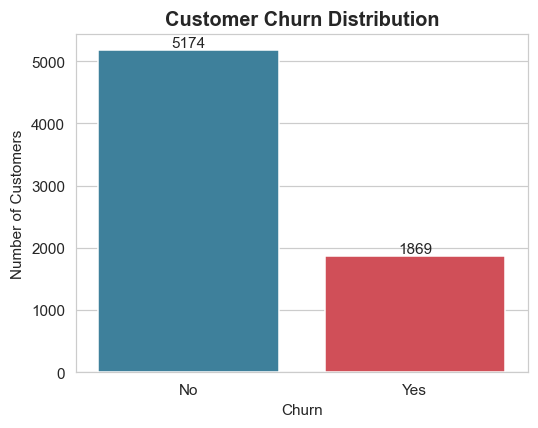

In [ ]:
# Churn distribution
plt.figure(figsize=(5,4))
ax= sns.countplot(x=df["Churn"].map({0:"No", 1:"Yes"}),palette=["#2E86AB", "#E63946"])
plt.title("Customer Churn Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show() 

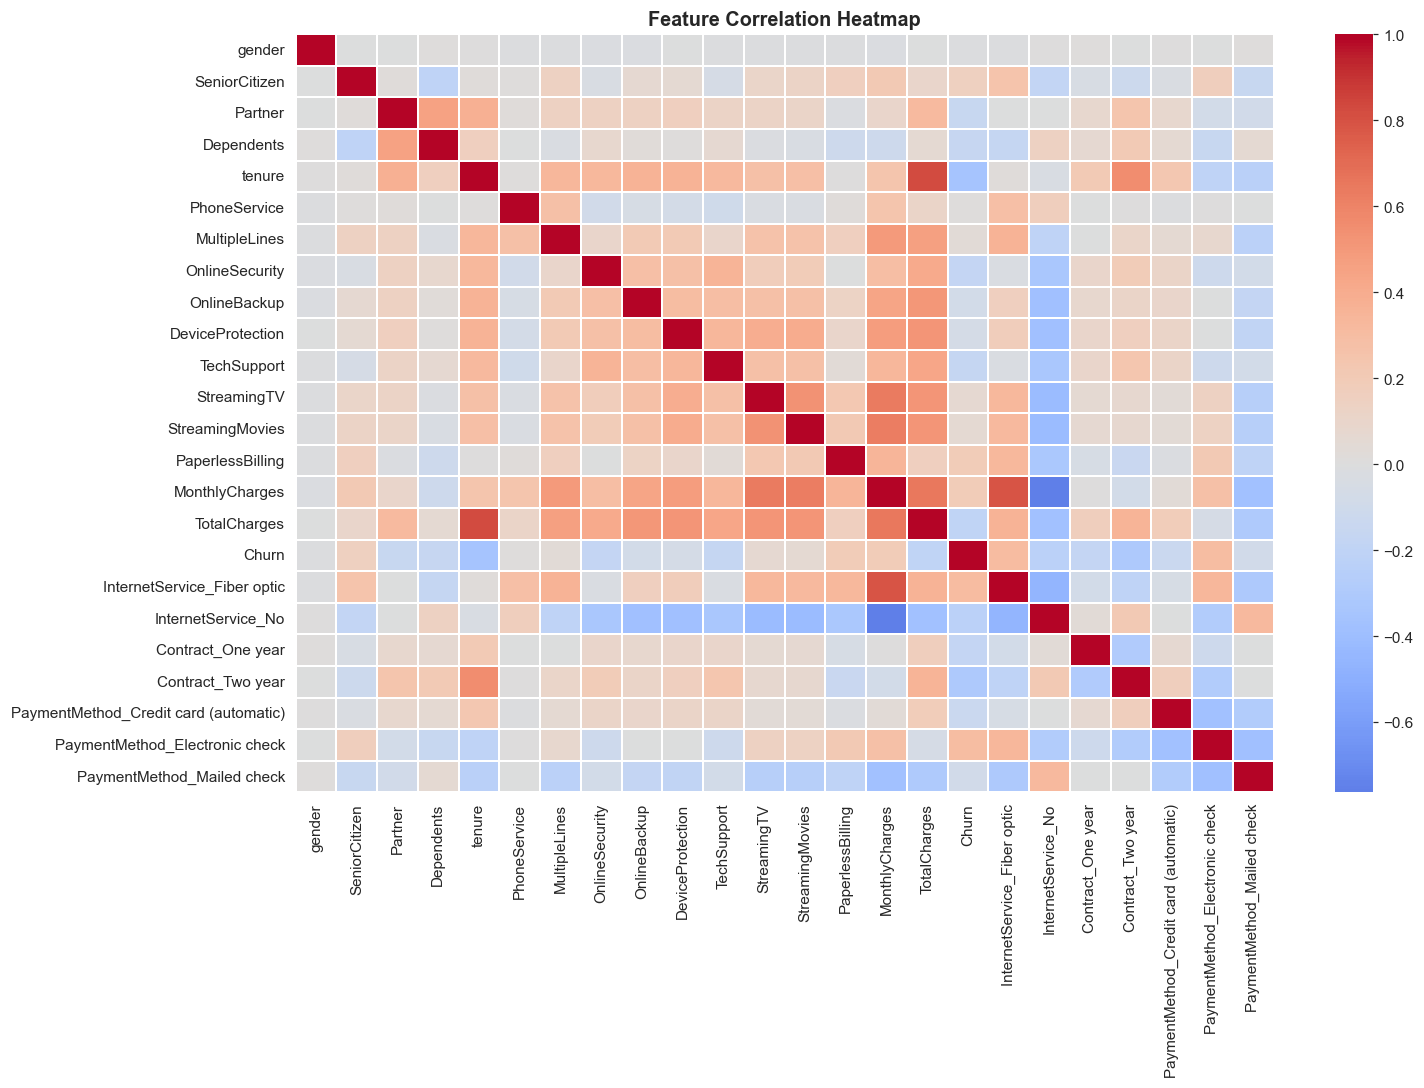

In [ ]:
# Correlation heatmap of numeric/encoded features
plt.figure(figsize=(14,10))
corr= df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\cz3\AppData\Local\Temp\ipykernel_15824\3085483960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y= churn_corr.index, palette="RdBu_r")


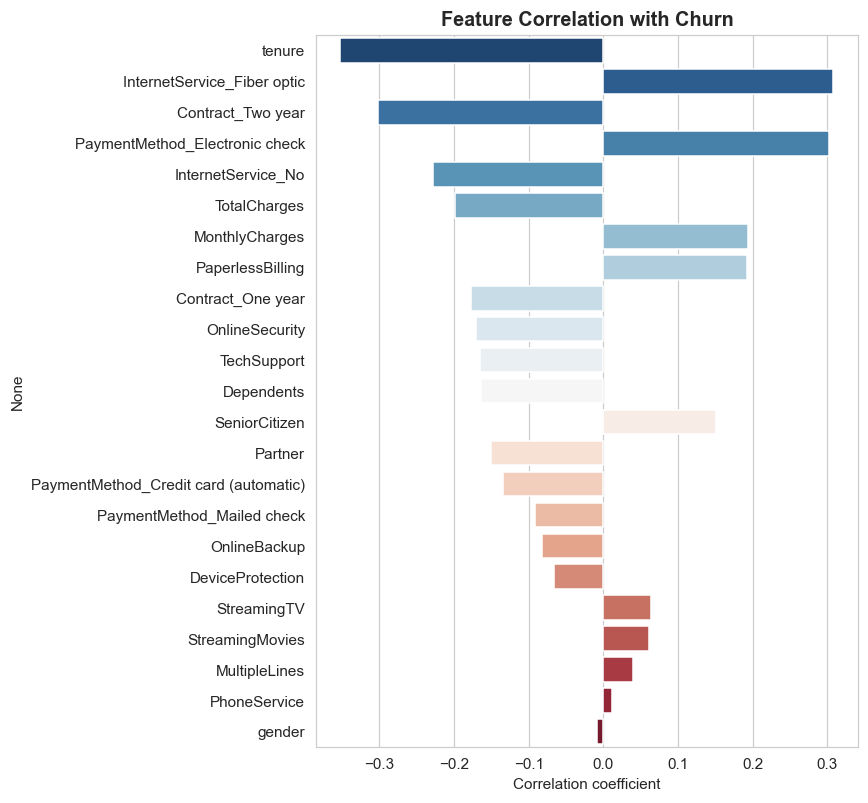

tenure                           -0.352229
InternetService_Fiber optic       0.308020
Contract_Two year                -0.302253
PaymentMethod_Electronic check    0.301919
InternetService_No               -0.227890
TotalCharges                     -0.198324
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
Contract_One year                -0.177820
OnlineSecurity                   -0.171226
Name: Churn, dtype: float64


In [ ]:
# Top correlations with Churn
churn_corr= corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8,7))
sns.barplot(x=churn_corr.values, y= churn_corr.index, palette="RdBu_r")
plt.tight_layout()
plt.title("Feature Correlation with Churn", fontsize=13, fontweight="bold")
plt.xlabel("Correlation coefficient")
plt.show()

print(churn_corr.head(10))

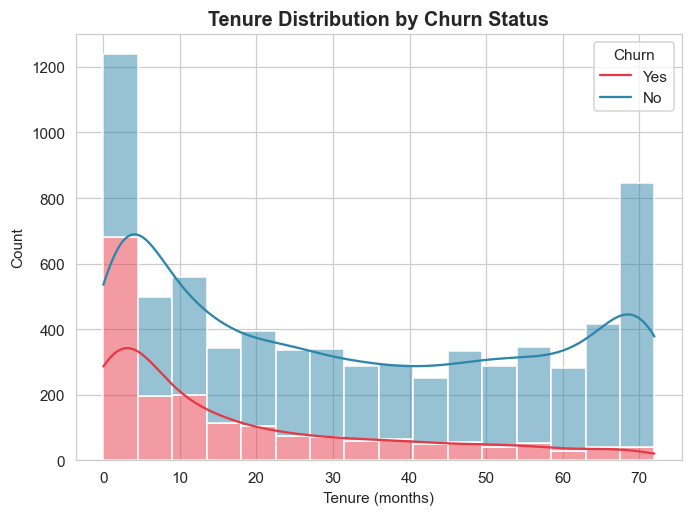

In [ ]:
# Tenure distribution by churn status
plt.Figure(figsize=(7,5))
sns.histplot(data=df, x="tenure", hue= df["Churn"].map({0:"No", 1:"Yes"}),
            kde= True, multiple="stack",palette=["#2E86AB", "#E63946"])
plt.title("Tenure Distribution by Churn Status", fontsize=13, fontweight="bold")
plt.xlabel("Tenure (months)")
plt.legend(title="Churn", labels= ["Yes", "No"])
plt.tight_layout()
plt.show()

**EDA Insights Summary:**
- Churn is concentrated heavily among **low-tenure customers**, new customers are the
  highest-risk segment.

## 5. Model Building and Evaluation

### Modeling Strategy
We train and compare **five classification algorithms** spanning different modeling
paradigms, linear, distance based, tree based, and ensemble methods, to find the best
trade off between predictive power and interpretability:

1. **Logistic Regression** — interpretable linear baseline
2. **K-Nearest Neighbors** — distance-based, non-parametric
3. **Decision Tree** — single interpretable tree, captures non-linear splits
4. **Random Forest** — bagged ensemble of trees, robust to overfitting
5. **Gradient Boosting** — sequential boosted ensemble, typically strongest raw performer

All numeric features are scaled with `StandardScaler` for the scale-sensitive models
(Logistic Regression, KNN). We use a stratified 80/20 train-test split to preserve the
class ratio in both sets.


In [ ]:
# Train/test split
X= df.drop(columns=["Churn"])
y= df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=random_state, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")

Training set: 5634 samples
Test set: 1409 samples
Train churn rate: 26.54% | Test churn rate: 26.54%


In [ ]:
# Feature scaling (fit on train only, to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 5.3 Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=random_state),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=random_state),
    "Gradient Boosting": GradientBoostingClassifier(random_state=random_state)
}

# Models that need scaled input vs raw (tree-based models don't need scaling)
scaled_models = {"Logistic Regression", "K-Nearest Neighbors"}

results = []
fitted_models = {}
proba_store = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model
    proba_store[name] = proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.807665,0.678201,0.524064,0.591252,0.843585
1,Gradient Boosting,0.798439,0.655172,0.508021,0.572289,0.842086
2,Logistic Regression,0.806955,0.659375,0.564171,0.608069,0.841923
3,Decision Tree,0.801278,0.667857,0.500000,0.571865,0.824404
4,K-Nearest Neighbors,0.774308,0.578652,0.550802,0.564384,0.806471


### Interpreting the Metrics
- **Accuracy** can be misleading here since a model that always predicts "No Churn" would
  still score ~73%.
- **Recall** (of the churn class) matters most operationally, it tells us what fraction of
  actual churners we successfully flag for a retention team to contact.
- **Precision** tells us how many of our flagged "at-risk" customers are true churners
  (relevant for the cost of retention offers).
- **ROC-AUC** gives an overall, threshold independent measure of separability between
  classes, and is our primary model selection metric.


## 7. Final Conclusion with Insights

### Model Performance Summary
Across all five algorithms, ensemble methods (**Random Forest** and **Gradient Boosting**)
delivered the strongest ROC-AUC, confirming that the relationship between customer
attributes and churn is meaningfully non-linear and benefits from tree-based interaction
capture. **Logistic Regression** remained a strong, highly interpretable baseline useful
if the business needs a transparent, auditable model (e.g., for regulatory or stakeholder
communication) rather than the absolute best raw score.